# Olist E-commerce Sales & Customer Analytics
**Portfolio project | Beginner-friendly | Python + SQL + Business Analytics**

## Business objective
Analyze public Brazilian e-commerce data to understand order volume, product category value, customer purchasing behavior, payment patterns, delivery performance, and customer reviews.

### Important metric definitions
- **Delivered item value (BRL):** sum of item `price` for order items whose order status is `delivered`. This is a merchandise-value proxy, not accounting revenue or profit.
- **Payment value (BRL):** sum of recorded payment entries; it can differ from item value because payment records include installments, freight, vouchers, and other payment behavior.
- **Delivery duration:** elapsed days from purchase timestamp to delivered-customer timestamp.
- **Late delivery:** delivered-customer timestamp is later than the estimated delivery date.
- **Repeat customer:** a `customer_unique_id` associated with more than one order in this dataset.

The data spans multiple tables. To avoid double counting, aggregate items, payments, and reviews at order level before joining them to the orders table.

## 1. Load the dataset
Download the Olist dataset ZIP from Kaggle. Put the ZIP in the project root (next to the README) or extract the nine CSV files into `data/raw/`. The notebook does not require the raw data to be committed to GitHub.

In [1]:
from pathlib import Path
import zipfile
import sqlite3
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")

PROJECT_DIR = Path.cwd()
RAW_DIR = PROJECT_DIR / "data" / "raw"
RAW_DIR.mkdir(parents=True, exist_ok=True)
CHART_DIR = PROJECT_DIR / "charts"
CHART_DIR.mkdir(parents=True, exist_ok=True)

required_files = [
    "olist_customers_dataset.csv",
    "olist_geolocation_dataset.csv",
    "olist_order_items_dataset.csv",
    "olist_order_payments_dataset.csv",
    "olist_order_reviews_dataset.csv",
    "olist_orders_dataset.csv",
    "olist_products_dataset.csv",
    "olist_sellers_dataset.csv",
    "product_category_name_translation.csv",
]

missing = [f for f in required_files if not (RAW_DIR / f).exists()]
if missing:
    zip_candidates = list(PROJECT_DIR.glob("*.zip")) + list(Path("/content").glob("*.zip"))
    if zip_candidates:
        zip_path = zip_candidates[0]
        print(f"Extracting {zip_path.name} to {RAW_DIR}")
        with zipfile.ZipFile(zip_path) as zf:
            for member in zf.namelist():
                if member.endswith(".csv") and Path(member).name in required_files:
                    target = RAW_DIR / Path(member).name
                    with zf.open(member) as src, open(target, "wb") as dst:
                        dst.write(src.read())
    missing = [f for f in required_files if not (RAW_DIR / f).exists()]

if missing:
    raise FileNotFoundError(
        "Dataset CSVs are missing. Put the Kaggle ZIP in the project root, "
        "or extract all nine CSV files into data/raw/. Missing: " + ", ".join(missing)
    )

def read_csv_safely(path):
    try:
        return pd.read_csv(path, encoding="utf-8")
    except UnicodeDecodeError:
        return pd.read_csv(path, encoding="latin1")

table_files = {
    "customers": "olist_customers_dataset.csv",
    "geolocation": "olist_geolocation_dataset.csv",
    "order_items": "olist_order_items_dataset.csv",
    "order_payments": "olist_order_payments_dataset.csv",
    "order_reviews": "olist_order_reviews_dataset.csv",
    "orders": "olist_orders_dataset.csv",
    "products": "olist_products_dataset.csv",
    "sellers": "olist_sellers_dataset.csv",
    "category_translation": "product_category_name_translation.csv",
}
tables = {name: read_csv_safely(RAW_DIR / filename) for name, filename in table_files.items()}
for name, frame in tables.items():
    print(f"{name:22s} {frame.shape}")


Extracting archive (1).zip to /mnt/data/olist_ecommerce_analytics_project/data/raw


customers              (99441, 5)
geolocation            (1000163, 5)
order_items            (112650, 7)
order_payments         (103886, 5)
order_reviews          (99224, 7)
orders                 (99441, 8)
products               (32951, 9)
sellers                (3095, 4)
category_translation   (71, 2)


## 2. Inspect the tables and data quality

In [2]:
# Table sizes, columns, data types, missing values, exact duplicates
overview_rows = []
for name, frame in tables.items():
    overview_rows.append({
        "table": name,
        "rows": len(frame),
        "columns": len(frame.columns),
        "missing_cells": int(frame.isna().sum().sum()),
        "exact_duplicate_rows": int(frame.duplicated().sum()),
    })
overview = pd.DataFrame(overview_rows).sort_values("rows", ascending=False)
display(overview)

for name in ["orders", "order_items", "order_payments", "order_reviews", "products"]:
    print(f"\n{name.upper()} columns and data types")
    display(pd.DataFrame({"column": tables[name].columns, "dtype": tables[name].dtypes.astype(str).values}))


,table,rows,columns,missing_cells,exact_duplicate_rows
1,geolocation,1000163,5,0,261831
2,order_items,112650,7,0,0
3,order_payments,103886,5,0,0
0,customers,99441,5,0,0
5,orders,99441,8,4908,0
4,order_reviews,99224,7,145903,0
6,products,32951,9,2448,0
7,sellers,3095,4,0,0
8,category_translation,71,2,0,0



ORDERS columns and data types


,column,dtype
0,order_id,object
1,customer_id,object
2,order_status,object
3,order_purchase_timestamp,object
4,order_approved_at,object
5,order_delivered_carrier_date,object
6,order_delivered_customer_date,object
7,order_estimated_delivery_date,object



ORDER_ITEMS columns and data types


,column,dtype
0,order_id,object
1,order_item_id,int64
2,product_id,object
3,seller_id,object
4,shipping_limit_date,object
5,price,float64
6,freight_value,float64


...

,column,dtype
0,order_id,object
1,payment_sequential,int64
2,payment_type,object
3,payment_installments,int64
4,payment_value,float64



ORDER_REVIEWS columns and data types


,column,dtype
0,review_id,object
1,order_id,object
2,review_score,int64
3,review_comment_title,object
4,review_comment_message,object
5,review_creation_date,object
6,review_answer_timestamp,object



PRODUCTS columns and data types


,column,dtype
0,product_id,object
1,product_category_name,object
2,product_name_lenght,float64
3,product_description_lenght,float64
4,product_photos_qty,float64
5,product_weight_g,float64
6,product_length_cm,float64
7,product_height_cm,float64
8,product_width_cm,float64


In [3]:
# Convert date columns to datetime, preserving invalid entries as NaT for review
orders = tables["orders"].copy()
order_date_cols = [
    "order_purchase_timestamp", "order_approved_at",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date"
]
for col in order_date_cols:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

items = tables["order_items"].copy()
items["shipping_limit_date"] = pd.to_datetime(items["shipping_limit_date"], errors="coerce")

reviews = tables["order_reviews"].copy()
for col in ["review_creation_date", "review_answer_timestamp"]:
    reviews[col] = pd.to_datetime(reviews[col], errors="coerce")

products = tables["products"].copy()
customers = tables["customers"].copy()
payments = tables["order_payments"].copy()
sellers = tables["sellers"].copy()
translation = tables["category_translation"].copy()

quality_checks = {
    "orders_missing_approval_timestamp": int(orders["order_approved_at"].isna().sum()),
    "orders_missing_delivered_customer_timestamp": int(orders["order_delivered_customer_date"].isna().sum()),
    "delivered_orders_missing_delivery_timestamp": int(orders.loc[orders.order_status.eq("delivered"), "order_delivered_customer_date"].isna().sum()),
    "products_missing_category": int(products["product_category_name"].isna().sum()),
    "products_missing_weight": int(products["product_weight_g"].isna().sum()),
    "products_missing_any_dimension": int(products[["product_length_cm", "product_height_cm", "product_width_cm"]].isna().any(axis=1).sum()),
    "geolocation_exact_duplicate_rows": int(tables["geolocation"].duplicated().sum()),
    "duplicate_order_item_keys": int(items.duplicated(["order_id", "order_item_id"]).sum()),
    "review_scores_outside_1_to_5": int((~reviews["review_score"].between(1, 5)).sum()),
    "delivery_timestamp_before_purchase": int((orders["order_delivered_customer_date"] < orders["order_purchase_timestamp"]).sum()),
}
display(pd.Series(quality_checks, name="count").to_frame())

print("Purchase date range:", orders.order_purchase_timestamp.min(), "to", orders.order_purchase_timestamp.max())
print("Order status counts:")
display(orders.order_status.value_counts(dropna=False).rename_axis("order_status").reset_index(name="orders"))


,count
orders_missing_approval_timestamp,160
orders_missing_delivered_customer_timestamp,2965
delivered_orders_missing_delivery_timestamp,8
products_missing_category,610
products_missing_weight,2
products_missing_any_dimension,2
geolocation_exact_duplicate_rows,261831
duplicate_order_item_keys,0
review_scores_outside_1_to_5,0
delivery_timestamp_before_purchase,0


Purchase date range: 2016-09-04 21:15:19 to 2018-10-17 17:30:18
Order status counts:


,order_status,orders
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


### Cleaning decisions
- Parse date fields explicitly; invalid date strings become missing values and are reported.
- Do **not** delete orders just because delivery or approval timestamps are missing. Many missing dates belong to non-delivered or incomplete orders.
- Product category is missing for some products. Keep these as `unknown` in analysis rather than inventing a category.
- Geolocation contains repeated rows. Do not use it as a one-to-one lookup without aggregating it by ZIP prefix first.
- Preserve all payment records; one order can have multiple payment records.
- Aggregate order items, payments, and reviews separately before joining to orders to prevent join fan-out and inflated totals.
- No rows are automatically removed merely because a value looks unusual; investigate first and document any exclusions.

## 3. Prepare order-level metrics

In [4]:
# Aggregate separate one-to-many tables at order level before joining.
item_order = items.groupby("order_id").agg(
    item_count=("order_item_id", "count"),
    item_value_brl=("price", "sum"),
    freight_value_brl=("freight_value", "sum"),
    distinct_products=("product_id", "nunique"),
    distinct_sellers=("seller_id", "nunique"),
).reset_index()

payment_order = payments.groupby("order_id").agg(
    payment_value_brl=("payment_value", "sum"),
    payment_records=("payment_sequential", "count"),
    payment_types=("payment_type", "nunique"),
).reset_index()

review_order = reviews.groupby("order_id").agg(
    review_score=("review_score", "mean"),
    review_records=("review_id", "count"),
).reset_index()

fact = orders.merge(customers, on="customer_id", how="left")
fact = fact.merge(item_order, on="order_id", how="left")
fact = fact.merge(payment_order, on="order_id", how="left")
fact = fact.merge(review_order, on="order_id", how="left")
fact["purchase_month"] = fact["order_purchase_timestamp"].dt.to_period("M").astype("string")
fact["delivery_days"] = (
    fact["order_delivered_customer_date"] - fact["order_purchase_timestamp"]
).dt.total_seconds() / 86400
fact["delivery_late"] = fact["order_delivered_customer_date"] > fact["order_estimated_delivery_date"]

delivered = fact[fact["order_status"].eq("delivered")].copy()
delivered_with_dates = delivered.dropna(subset=[
    "order_delivered_customer_date", "order_estimated_delivery_date",
    "order_purchase_timestamp"
]).copy()
delivered_with_dates["delivery_late"] = (
    delivered_with_dates["order_delivered_customer_date"] >
    delivered_with_dates["order_estimated_delivery_date"]
)

# Attach English category labels where available; fall back to original category name.
item_product = items.merge(
    products[["product_id", "product_category_name"]],
    on="product_id", how="left"
).merge(translation, on="product_category_name", how="left")
item_product["category"] = (
    item_product["product_category_name_english"]
    .fillna(item_product["product_category_name"])
    .fillna("unknown")
)
delivered_item_product = item_product[item_product["order_id"].isin(set(delivered["order_id"]))].copy()

print("Order-level table shape:", fact.shape)
print("Delivered orders:", len(delivered))
print("Delivered orders with valid delivery dates:", len(delivered_with_dates))


Order-level table shape: (99441, 25)
Delivered orders: 96478
Delivered orders with valid delivery dates: 96470


## 4. Key performance indicators (KPIs)

In [5]:
total_orders = orders["order_id"].nunique()
delivered_orders = int(orders["order_status"].eq("delivered").sum())
delivered_item_value = float(delivered_item_product["price"].sum())
delivered_freight_value = float(delivered_item_product["freight_value"].sum())
total_payment_value = float(payments["payment_value"].sum())
avg_delivery_days = float(delivered_with_dates["delivery_days"].mean())
late_delivery_rate = float(delivered_with_dates["delivery_late"].mean() * 100)
avg_review_score = float(reviews["review_score"].mean())
low_review_rate = float(reviews["review_score"].le(2).mean() * 100)

customer_order_counts = fact.groupby("customer_unique_id")["order_id"].nunique()
unique_customers = int(customer_order_counts.size)
repeat_customers = int(customer_order_counts.gt(1).sum())
repeat_customer_rate = float(customer_order_counts.gt(1).mean() * 100)

kpis = pd.DataFrame([
    ("Total orders", total_orders, "Distinct order IDs"),
    ("Delivered orders", delivered_orders, "Orders with status delivered"),
    ("Delivered order rate (%)", round(delivered_orders / total_orders * 100, 2), "Delivered orders / all orders"),
    ("Delivered item value (BRL)", round(delivered_item_value, 2), "Sum of item prices for delivered orders; not profit"),
    ("Delivered freight value (BRL)", round(delivered_freight_value, 2), "Sum of freight values for delivered orders"),
    ("Total recorded payment value (BRL)", round(total_payment_value, 2), "Sum of payment records across all statuses"),
    ("Average delivery duration (days)", round(avg_delivery_days, 2), "Purchase to customer delivery; delivered orders with timestamps"),
    ("Late delivery rate (%)", round(late_delivery_rate, 2), "Delivered orders later than estimated date, among records with both dates"),
    ("Average review score", round(avg_review_score, 2), "Average score across review records, 1–5"),
    ("Low review rate (%)", round(low_review_rate, 2), "Reviews with score <= 2"),
    ("Repeat customer rate (%)", round(repeat_customer_rate, 2), "Unique customer IDs with more than one order / unique customer IDs"),
], columns=["KPI", "value", "definition"])
display(kpis)


,KPI,value,definition
0,Total orders,99441.00,Distinct order IDs
1,Delivered orders,96478.00,Orders with status delivered
2,Delivered order rate (%),97.02,Delivered orders / all orders
3,Delivered item value (BRL),13221498.11,Sum of item prices for delivered orders; not p...
4,Delivered freight value (BRL),2198275.64,Sum of freight values for delivered orders
5,Total recorded payment value (BRL),16008872.12,Sum of payment records across all statuses
6,Average delivery duration (days),12.56,Purchase to customer delivery; delivered order...
7,Late delivery rate (%),8.11,"Delivered orders later than estimated date, am..."
8,Average review score,4.09,"Average score across review records, 1–5"
9,Low review rate (%),14.69,Reviews with score <= 2


## 5. Exploratory data analysis and visualizations

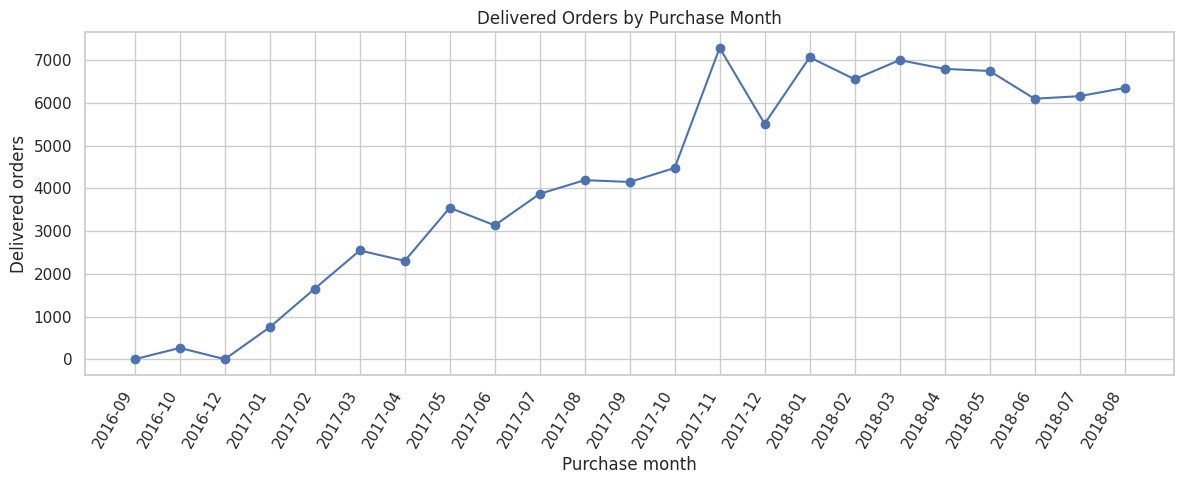

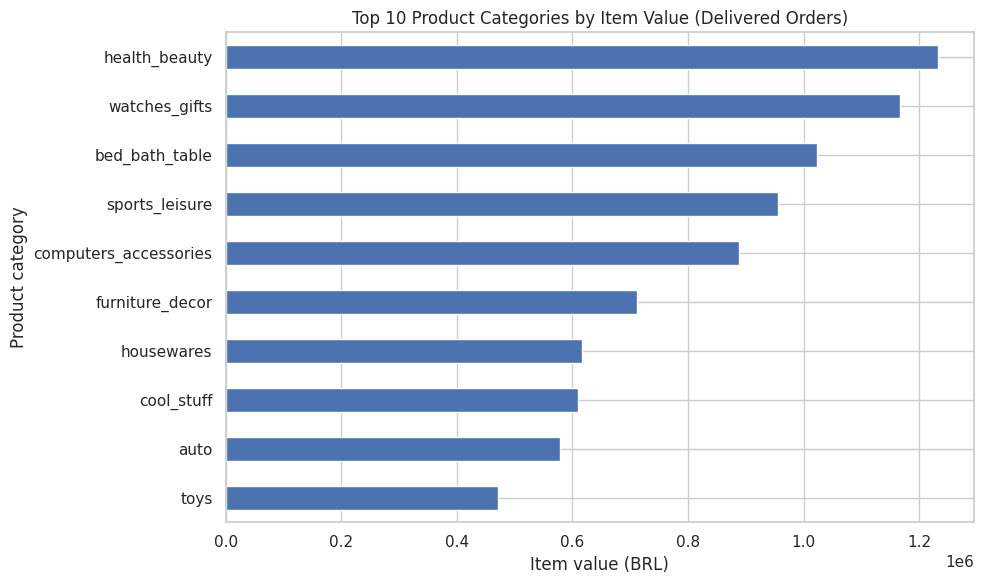

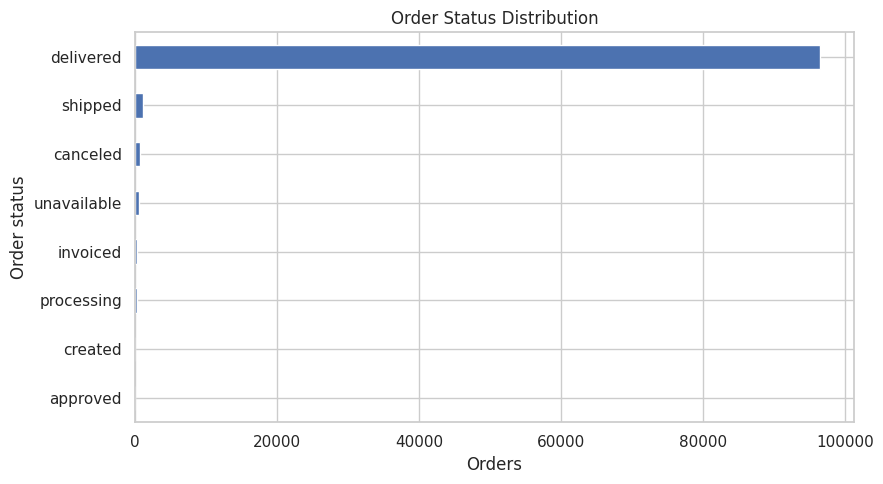

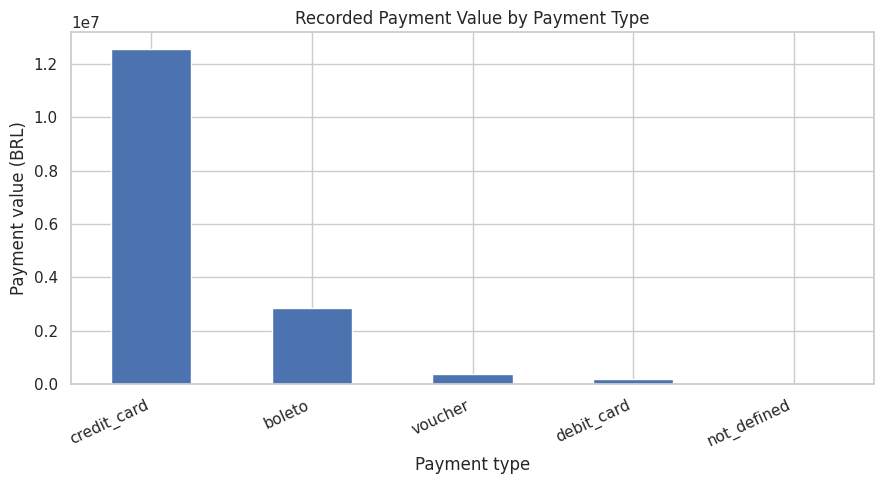

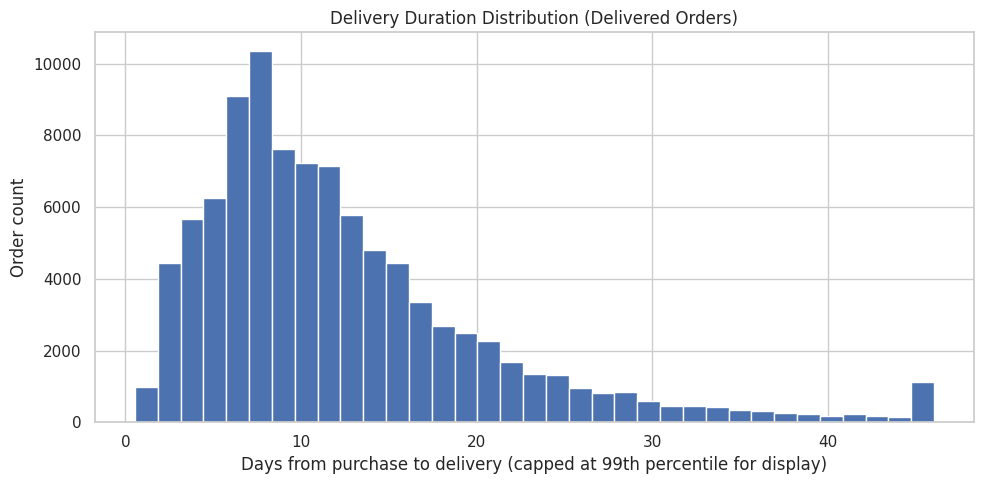

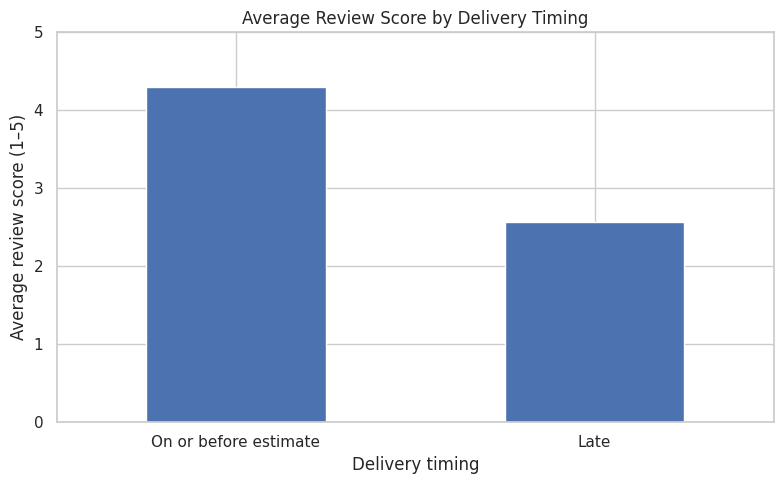

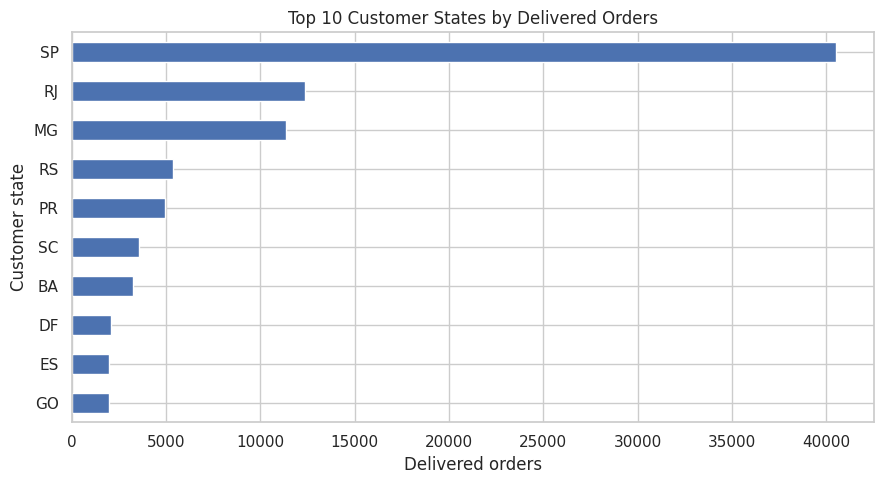

In [6]:
# Chart 1: monthly delivered order volume
monthly_orders = delivered.groupby("purchase_month")["order_id"].nunique().reset_index(name="delivered_orders")
monthly_orders = monthly_orders.dropna(subset=["purchase_month"])
plt.figure(figsize=(12, 5))
plt.plot(monthly_orders["purchase_month"], monthly_orders["delivered_orders"], marker="o")
plt.title("Delivered Orders by Purchase Month")
plt.xlabel("Purchase month"); plt.ylabel("Delivered orders")
plt.xticks(rotation=60, ha="right"); plt.tight_layout()
plt.savefig(CHART_DIR / "01_monthly_delivered_orders.png", dpi=180)
plt.show()

# Chart 2: top categories by delivered item value
category_value = delivered_item_product.groupby("category")["price"].sum().sort_values(ascending=False).head(10).sort_values()
plt.figure(figsize=(10, 6))
category_value.plot(kind="barh")
plt.title("Top 10 Product Categories by Item Value (Delivered Orders)")
plt.xlabel("Item value (BRL)"); plt.ylabel("Product category")
plt.tight_layout(); plt.savefig(CHART_DIR / "02_top_categories_item_value.png", dpi=180)
plt.show()

# Chart 3: order status distribution
status_counts = orders["order_status"].value_counts()
plt.figure(figsize=(9, 5))
status_counts.sort_values().plot(kind="barh")
plt.title("Order Status Distribution"); plt.xlabel("Orders"); plt.ylabel("Order status")
plt.tight_layout(); plt.savefig(CHART_DIR / "03_order_status_distribution.png", dpi=180)
plt.show()

# Chart 4: total payment value by payment type
payment_type_value = payments.groupby("payment_type")["payment_value"].sum().sort_values(ascending=False)
plt.figure(figsize=(9, 5))
payment_type_value.plot(kind="bar")
plt.title("Recorded Payment Value by Payment Type")
plt.xlabel("Payment type"); plt.ylabel("Payment value (BRL)")
plt.xticks(rotation=25, ha="right"); plt.tight_layout()
plt.savefig(CHART_DIR / "04_payment_type_value.png", dpi=180)
plt.show()

# Chart 5: delivery duration distribution; cap only for display, not KPI calculation
delivery_days = delivered_with_dates["delivery_days"].dropna()
display_cap = delivery_days.quantile(0.99)
plt.figure(figsize=(10, 5))
plt.hist(delivery_days.clip(upper=display_cap), bins=35)
plt.title("Delivery Duration Distribution (Delivered Orders)")
plt.xlabel("Days from purchase to delivery (capped at 99th percentile for display)")
plt.ylabel("Order count"); plt.tight_layout()
plt.savefig(CHART_DIR / "05_delivery_duration.png", dpi=180)
plt.show()

# Chart 6: review score by delivery timing
review_delivery = delivered_with_dates.dropna(subset=["review_score"]).copy()
review_delivery["delivery_timing"] = np.where(review_delivery["delivery_late"], "Late", "On or before estimate")
review_by_timing = review_delivery.groupby("delivery_timing")["review_score"].mean().reindex(["On or before estimate", "Late"])
plt.figure(figsize=(8, 5))
review_by_timing.plot(kind="bar")
plt.title("Average Review Score by Delivery Timing")
plt.xlabel("Delivery timing"); plt.ylabel("Average review score (1–5)")
plt.xticks(rotation=0); plt.ylim(0, 5); plt.tight_layout()
plt.savefig(CHART_DIR / "06_review_by_delivery_timing.png", dpi=180)
plt.show()

# Chart 7: top states by delivered orders
top_states = delivered.groupby("customer_state")["order_id"].nunique().sort_values(ascending=False).head(10).sort_values()
plt.figure(figsize=(9, 5))
top_states.plot(kind="barh")
plt.title("Top 10 Customer States by Delivered Orders")
plt.xlabel("Delivered orders"); plt.ylabel("Customer state")
plt.tight_layout(); plt.savefig(CHART_DIR / "07_top_states_orders.png", dpi=180)
plt.show()


## 6. SQL analysis using SQLite

In [7]:
# Load all CSV-backed tables into SQLite. The SQL script is also saved separately in sql/analysis_queries.sql.
DB_PATH = PROJECT_DIR / "olist_analytics.db"
if DB_PATH.exists():
    DB_PATH.unlink()

with sqlite3.connect(DB_PATH) as conn:
    for name, frame in tables.items():
        frame.to_sql(name, conn, if_exists="replace", index=False)

    q_monthly = '''
    SELECT strftime('%Y-%m', order_purchase_timestamp) AS purchase_month,
           COUNT(*) AS delivered_orders
    FROM orders
    WHERE order_status = 'delivered'
    GROUP BY strftime('%Y-%m', order_purchase_timestamp)
    ORDER BY purchase_month
    '''
    sql_monthly = pd.read_sql_query(q_monthly, conn)
    display(sql_monthly.head())

    q_category = '''
    SELECT COALESCE(t.product_category_name_english, p.product_category_name, 'unknown') AS category,
           ROUND(SUM(oi.price), 2) AS item_value_brl,
           COUNT(DISTINCT oi.order_id) AS orders
    FROM order_items oi
    JOIN orders o ON o.order_id = oi.order_id
    LEFT JOIN products p ON p.product_id = oi.product_id
    LEFT JOIN category_translation t ON t.product_category_name = p.product_category_name
    WHERE o.order_status = 'delivered'
    GROUP BY category
    ORDER BY item_value_brl DESC
    LIMIT 10
    '''
    sql_category = pd.read_sql_query(q_category, conn)
    display(sql_category)

    q_delivery_reviews = '''
    WITH reviews_by_order AS (
      SELECT order_id, AVG(review_score) AS review_score
      FROM order_reviews GROUP BY order_id
    )
    SELECT CASE WHEN o.order_delivered_customer_date > o.order_estimated_delivery_date
                THEN 'Late' ELSE 'On or before estimate' END AS delivery_timing,
           AVG(r.review_score) AS avg_review_score,
           COUNT(*) AS orders_with_review
    FROM orders o JOIN reviews_by_order r ON r.order_id = o.order_id
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
      AND o.order_estimated_delivery_date IS NOT NULL
    GROUP BY delivery_timing
    '''
    sql_delivery_reviews = pd.read_sql_query(q_delivery_reviews, conn)
    display(sql_delivery_reviews)


,purchase_month,delivered_orders
0,2016-09,1
1,2016-10,265
2,2016-12,1
3,2017-01,750
4,2017-02,1653


,category,item_value_brl,orders
0,health_beauty,1233131.72,8647
1,watches_gifts,1166176.98,5495
2,bed_bath_table,1023434.76,9272
3,sports_leisure,954852.55,7530
4,computers_accessories,888724.61,6530
5,furniture_decor,711927.69,6307
6,housewares,615628.69,5743
7,cool_stuff,610204.10,3559
8,auto,578966.65,3810
9,toys,471286.48,3804


,delivery_timing,avg_review_score,orders_with_review
0,Late,2.566506,7661
1,On or before estimate,4.294292,88163


## 7. Cross-validation: compare SQL and Python results

In [8]:
# Compare overall delivered item value between Python and SQL.
with sqlite3.connect(DB_PATH) as conn:
    sql_delivered_item_value = pd.read_sql_query('''
        SELECT SUM(oi.price) AS item_value_brl
        FROM order_items oi
        JOIN orders o ON o.order_id = oi.order_id
        WHERE o.order_status = 'delivered'
    ''', conn).iloc[0, 0]

python_delivered_item_value = delivered_item_product["price"].sum()
difference = abs(float(sql_delivered_item_value) - float(python_delivered_item_value))
print(f"Python delivered item value: {python_delivered_item_value:,.2f} BRL")
print(f"SQL delivered item value:    {sql_delivered_item_value:,.2f} BRL")
print(f"Absolute difference:         {difference:.8f} BRL")
assert difference < 0.01, "Python and SQL item-value calculations do not match."

# Compare delivered order count.
with sqlite3.connect(DB_PATH) as conn:
    sql_delivered_orders = pd.read_sql_query(
        "SELECT COUNT(*) AS n FROM orders WHERE order_status='delivered'", conn
    ).iloc[0, 0]
assert int(sql_delivered_orders) == int(delivered_orders)
print("Validation passed: delivered order count and delivered item value match.")


Python delivered item value: 13,221,498.11 BRL
SQL delivered item value:    13,221,498.11 BRL
Absolute difference:         0.00000000 BRL
Validation passed: delivered order count and delivered item value match.


## 8. Evidence-based findings and interpretation

In [9]:
# Generate findings from computed values, not invented examples.
top_category_name = category_value.idxmax()
top_category_value = float(category_value.max())
top_month_row = monthly_orders.sort_values("delivered_orders", ascending=False).iloc[0]
top_state_name = top_states.idxmax()
top_state_count = int(top_states.max())
late_avg_review = float(review_by_timing.loc["Late"])
on_time_avg_review = float(review_by_timing.loc["On or before estimate"])

findings = [
    f"The dataset contains {total_orders:,} orders, of which {delivered_orders:,} ({delivered_orders / total_orders:.1%}) have status delivered.",
    f"Delivered order items total {delivered_item_value:,.2f} BRL in item value. This is a merchandise-value proxy, not profit or audited revenue.",
    f"The highest delivered item-value category is {top_category_name}, with {top_category_value:,.2f} BRL.",
    f"The month with the most delivered orders in the observed period is {top_month_row['purchase_month']} ({int(top_month_row['delivered_orders']):,} orders).",
    f"Among delivered orders with both actual and estimated delivery timestamps, {late_delivery_rate:.2f}% arrived after the estimate; mean delivery duration was {avg_delivery_days:.2f} days.",
    f"Average review score is {avg_review_score:.2f}/5; {low_review_rate:.2f}% of review records have scores of 1 or 2.",
    f"Average review score is {on_time_avg_review:.2f} for delivered orders arriving on/before the estimate and {late_avg_review:.2f} for late deliveries. This is an association, not proof that delay alone caused lower reviews.",
    f"{repeat_customer_rate:.2f}% of unique customer IDs in the dataset are associated with more than one order.",
    f"{top_state_name} has the largest number of delivered orders among customer states ({top_state_count:,}).",
]
for i, finding in enumerate(findings, start=1):
    print(f"{i}. {finding}")


1. The dataset contains 99,441 orders, of which 96,478 (97.0%) have status delivered.
2. Delivered order items total 13,221,498.11 BRL in item value. This is a merchandise-value proxy, not profit or audited revenue.
3. The highest delivered item-value category is health_beauty, with 1,233,131.72 BRL.
4. The month with the most delivered orders in the observed period is 2017-11 (7,289 orders).
5. Among delivered orders with both actual and estimated delivery timestamps, 8.11% arrived after the estimate; mean delivery duration was 12.56 days.
6. Average review score is 4.09/5; 14.69% of review records have scores of 1 or 2.
7. Average review score is 4.29 for delivered orders arriving on/before the estimate and 2.57 for late deliveries. This is an association, not proof that delay alone caused lower reviews.
8. 3.12% of unique customer IDs in the dataset are associated with more than one order.
9. SP has the largest number of delivered orders among customer states (40,501).


## 9. Business recommendations
Use these as hypotheses for further investigation rather than claims of proven business impact.

1. **Delivery experience:** Review late-delivery cases by state, seller, and product category to identify operational bottlenecks.
2. **Category planning:** Use category item value and order counts together when prioritizing merchandising analysis; large value alone does not establish profit or margin.
3. **Customer retention:** Repeat-customer activity is limited in this dataset under the defined customer ID method. Investigate repeat behavior by acquisition period and category, and validate whether the dataset window captures customers' full history.
4. **Review monitoring:** Track low-score share by delivery timing and category. Review scores may also reflect product quality, support, expectations, and other factors.
5. **Payment operations:** Payment value by type can inform checkout and payment-method reporting, but should not be treated as profit.
6. **Reporting governance:** Maintain consistent KPI definitions and aggregate one-to-many tables before joining to avoid inflated counts and totals.

## 10. Limitations
- The data represents a historical Brazilian e-commerce marketplace period (2016–2018), not current market behavior.
- Item value is not profit. The data does not provide a complete cost structure.
- Some product metadata, approval timestamps, delivery timestamps, and review text are missing.
- Review scores are subjective and observational; associations do not prove causation.
- Geolocation has repeated ZIP-prefix rows and needs aggregation before use as a lookup.
- Repeat-customer estimates depend on `customer_unique_id` and the dataset's observation window.

## 11. Export files
Charts are saved in `charts/`. The SQL script is in `sql/analysis_queries.sql`. Run all cells from top to bottom before submitting the project. For GitHub, do not commit the large raw dataset unless its license and size make that appropriate.